# Load Data

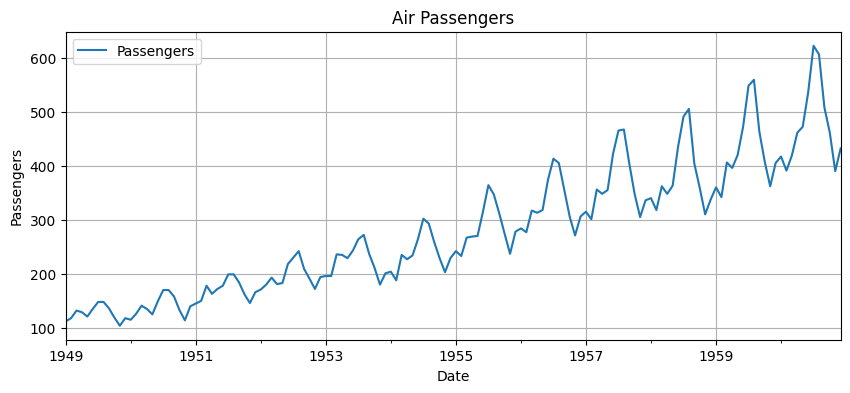

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="statsmodels")


# Load the AirPassengers dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Visualize the series
df.plot(figsize=(10, 4), title="Air Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid()
plt.show()

# Split Data

In [2]:
lag = 12
X = df['Passengers'][:-lag]
y = df['Passengers'][lag:]

# Define sizes
n = len(X)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

# Split the series
X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

# Confirm sizes
print(f"Train starts on: {X_train.index[0]}, Train ends on: {X_train.index[-1]}")
print(f"Validation starts on: {X_val.index[0]}, Validation ends on: {X_val.index[-1]}")
print(f"Test starts on: {X_test.index[0]}, Test ends on: {X_test.index[-1]}")
print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train starts on: 1949-01-01 00:00:00, Train ends on: 1956-08-01 00:00:00
Validation starts on: 1956-09-01 00:00:00, Validation ends on: 1958-03-01 00:00:00
Test starts on: 1958-04-01 00:00:00, Test ends on: 1959-12-01 00:00:00
Train size: 92, Val size: 19, Test size: 21


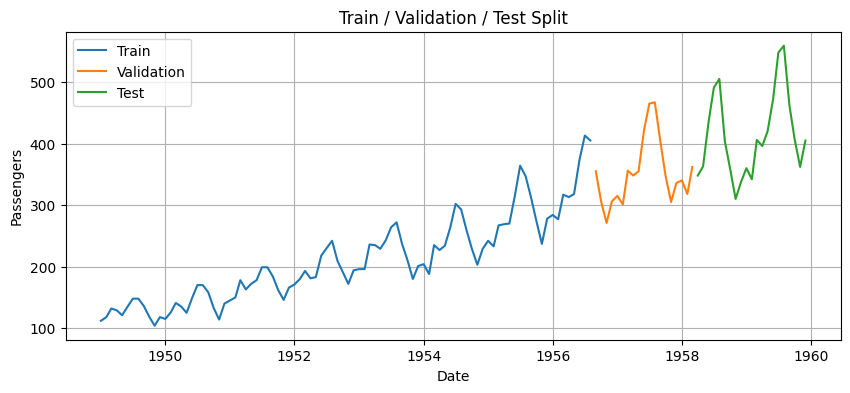

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(X_train, label="Train")
plt.plot(X_val, label="Validation")
plt.plot(X_test, label="Test")
plt.title("Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()

# Base Models

In [4]:
from abc import ABC, abstractmethod
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from copy import deepcopy

class AbstractBaseModel (ABC):

    def __init__(self, model, hparams, *args, **kwagrs):
        self.model = model
        self.hparams = hparams
        self.fitness_score = 0.0
        self.forecast = None

    @abstractmethod
    def train(self, X_train, y_train):
        raise NotImplementedError("Subclasses must implement train method")

    @abstractmethod
    def predict(self, X_test):
        raise NotImplementedError("Subclasses must implement predict method")

    @abstractmethod
    def get_name(self):
        raise NotImplementedError("Subclasses must implement get_name method")
    
    @abstractmethod
    def crossover(self, other):
        raise NotImplementedError("Subclasses must implement crossover method")

    @abstractmethod
    def mutate(self):
        raise NotImplementedError("Subclasses must implement mutate method")
    
    def calculate_fitness(self, pred, y_test, diversity_score):
        alpha = 0.9
        beta = 0.1
        self.fitness_score = (alpha * 1/(np.sqrt(mean_squared_error(y_test, pred)) + 1e-8)) + (beta * diversity_score)
        return self.fitness_score
    
    def __str__(self):
        return str(type(self).__name__) + ' ' + str(self.hparams) + ' Fitness: ' + str(self.fitness_score)
    
    def __repr__(self):
        return str(type(self).__name__) + ' ' + str(self.hparams) + ' Fitness: ' + str(self.fitness_score)


class SarimaModel(AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._X_train = None  # cache training data for fallback retraining
    
    def train(self, X_train, y_train):
        self._X_train = X_train
        p = self.hparams['p']
        d = self.hparams['d']
        q = self.hparams['q']
        s = self.hparams['s']
        try:
            if s > 1:
                self.model = SARIMAX(
                    X_train, order=(p, d, q), seasonal_order=(p, d, q, s)
                ).fit(disp=False)
            else:
                # s=0 or s=1 means no seasonal component
                self.model = SARIMAX(X_train, order=(p, d, q)).fit(disp=False)
        except Exception:
            # Fallback to ARIMA(1,1,1) when the chosen params fail to converge
            self.hparams.update({'p': 1, 'd': 1, 'q': 1, 's': 0})
            self.model = SARIMAX(X_train, order=(1, 1, 1)).fit(disp=False)
    
    def predict(self, X_test):
        self.forecast = self.model.forecast(steps=len(X_test))
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'sarima'
    
    def crossover(self, other):
        if not isinstance(other, SarimaModel):
            raise ValueError("Can only crossover with another SarimaModel")
        
        child1 = deepcopy(self)
        child2 = deepcopy(other)
        
        if np.random.random() < 0.5:
            child1.hparams['p'], child2.hparams['p'] = child2.hparams['p'], child1.hparams['p']
        if np.random.random() < 0.5:
            child1.hparams['d'], child2.hparams['d'] = child2.hparams['d'], child1.hparams['d']
        if np.random.random() < 0.5:
            child1.hparams['q'], child2.hparams['q'] = child2.hparams['q'], child1.hparams['q']
        if np.random.random() < 0.5:
            child1.hparams['s'], child2.hparams['s'] = child2.hparams['s'], child1.hparams['s']
        
        child1.fitness_score = 0.0
        child2.fitness_score = 0.0
        
        return child1, child2
    
    def mutate(self):
        mutation_param = np.random.choice(['p', 'd', 'q', 's'])
        
        if mutation_param == 'p':
            self.hparams['p'] = np.random.randint(0, 5)
        elif mutation_param == 'd':
            self.hparams['d'] = np.random.randint(0, 2)
        elif mutation_param == 'q':
            self.hparams['q'] = np.random.randint(0, 5)
        elif mutation_param == 's':
            # 0 means non-seasonal; consistent with init_population choices
            self.hparams['s'] = np.random.choice([0, 2, 3, 4, 6, 12])
        
        self.fitness_score = 0.0
        
        return self

class SVRModel (AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, X_train, y_train):
        kernel = self.hparams['kernel']
        c = self.hparams['c']
        gamma = self.hparams['gamma']
        epsilon = self.hparams['epsilon']
        self.model = SVR(kernel=kernel, C=c, gamma=gamma, epsilon=epsilon)
        self.model.fit(X_train, y_train)
    
    def predict(self, X_test):
        self.forecast = self.model.predict(X_test)
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'svr'
    
    def crossover(self, other):
        if not isinstance(other, SVRModel):
            raise ValueError("Can only crossover with another SVRModel")
        
        child1 = deepcopy(self)
        child2 = deepcopy(other)
        
        if np.random.random() < 0.5:
            child1.hparams['kernel'], child2.hparams['kernel'] = child2.hparams['kernel'], child1.hparams['kernel']
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            c1, c2 = child1.hparams['c'], child2.hparams['c']
            child1.hparams['c'] = alpha * c1 + (1 - alpha) * c2
            child2.hparams['c'] = alpha * c2 + (1 - alpha) * c1
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            eps1, eps2 = child1.hparams['epsilon'], child2.hparams['epsilon']
            child1.hparams['epsilon'] = alpha * eps1 + (1 - alpha) * eps2
            child2.hparams['epsilon'] = alpha * eps2 + (1 - alpha) * eps1
        
        child1.fitness_score = 0.0
        child2.fitness_score = 0.0
        
        return child1, child2
    
    def mutate(self):
        
        # Randomly select which parameter to mutate
        mutation_param = np.random.choice(['kernel', 'c', 'epsilon'])
        
        if mutation_param == 'kernel':
            self.hparams['kernel'] = np.random.choice(["linear", "rbf", "poly"])
        
        elif mutation_param == 'c':
            current_c = self.hparams['c']
            noise = np.random.normal(0, current_c * 0.1)  # 10% noise
            self.hparams['c'] = max(0.1, min(100, current_c + noise))
        
        elif mutation_param == 'epsilon':
            current_eps = self.hparams['epsilon']
            noise = np.random.normal(0, current_eps * 0.1)  # 10% noise
            self.hparams['epsilon'] = max(0.001, min(0.5, current_eps + noise))

        self.fitness_score = 0.0
        
        return self
    
class MLPModel (AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, X_train, y_train):
        hidden_layer_sizes = self.hparams['hidden_layer_sizes']
        learning_rate = self.hparams['learning_rate']
        
        hidden_layer_sizes = (int(hidden_layer_sizes),)
        
        self.model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes,
                            learning_rate_init=learning_rate,
                            max_iter=500, random_state=42)
        self.model.fit(X_train, y_train)
    
    def predict(self, X_test):
        self.forecast = self.model.predict(X_test)
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'mlp'
    
    def crossover(self, other):
        if not isinstance(other, MLPModel):
            raise ValueError("Can only crossover with another MLPModel")
        
        child1 = deepcopy(self)
        child2 = deepcopy(other)
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            h1, h2 = child1.hparams['hidden_layer_sizes'], child2.hparams['hidden_layer_sizes']
            child1.hparams['hidden_layer_sizes'] = int(alpha * h1 + (1 - alpha) * h2)
            child2.hparams['hidden_layer_sizes'] = int(alpha * h2 + (1 - alpha) * h1)
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            lr1, lr2 = child1.hparams['learning_rate'], child2.hparams['learning_rate']
            child1.hparams['learning_rate'] = alpha * lr1 + (1 - alpha) * lr2
            child2.hparams['learning_rate'] = alpha * lr2 + (1 - alpha) * lr1
        
        child1.fitness_score = 0.0
        child2.fitness_score = 0.0
        
        return child1, child2
    
    def mutate(self):
        
        # Randomly select which parameter to mutate
        mutation_param = np.random.choice(['hidden_layer_sizes', 'learning_rate'])
        
        if mutation_param == 'hidden_layer_sizes':
            current_size = self.hparams['hidden_layer_sizes']
            change = np.random.randint(-10, 11)  # Change by -10 to +10
            self.hparams['hidden_layer_sizes'] = max(5, min(50, current_size + change))
        
        elif mutation_param == 'learning_rate':
            current_lr = self.hparams['learning_rate']
            noise = np.random.normal(0, current_lr * 0.1)  # 10% noise
            self.hparams['learning_rate'] = max(0.001, min(0.1, current_lr + noise))

        self.fitness_score = 0.0
        
        return self

    
class EnsembleModel (AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, X_train, y_train):
        for model in self.hparams.keys():
            self.hparams[model].train(X_train, y_train)
    
    def predict(self, X_test):
        self.forecast = 0.0
        for model in self.hparams.keys():
            self.forecast += self.hparams[model].predict(X_test)
        self.forecast /= len(self.hparams.keys()) # Average of all predictions
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'ensemble'
    
    def crossover(self, other):
        return self, other
    
    def mutate(self):
        return self


# Evaluation

In [5]:
def plot_forecasts(models, actual, save_path=None, show=True, label=None):
    plt.figure(figsize=(10, 4))
    plt.plot(actual, label='Actual')
    for model in models:
        plt.plot(model.forecast, label=model.get_name())
    if label:
        plt.gca().text(0.02, 0.97, label, transform=plt.gca().transAxes,
                       fontsize=12, verticalalignment='top',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    plt.grid()
    plt.legend(loc='upper right')
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close()

# Grid Search

In [6]:
import os
from copy import deepcopy
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler


class SarimaEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, p=1, d=1, q=1, s=0):
        self.p = p
        self.d = d
        self.q = q
        self.s = s

    def fit(self, X, y=None):
        X_1d = np.array(X).ravel()
        try:
            if self.s > 1:
                self.model_ = SARIMAX(X_1d, order=(self.p, self.d, self.q),
                                      seasonal_order=(self.p, self.d, self.q, self.s)).fit(disp=False)
            else:
                self.model_ = SARIMAX(X_1d, order=(self.p, self.d, self.q)).fit(disp=False)
        except Exception:
            self.model_ = SARIMAX(X_1d, order=(1, 1, 1)).fit(disp=False)
        return self

    def predict(self, X):
        return self.model_.forecast(steps=len(X))


class SVREstimator(BaseEstimator, RegressorMixin):
    def __init__(self, kernel='rbf', c=1.0, gamma='scale', epsilon=0.1):
        self.kernel = kernel
        self.c = c
        self.gamma = gamma
        self.epsilon = epsilon

    def fit(self, X, y):
        self.model_ = SVR(kernel=self.kernel, C=self.c, gamma=self.gamma, epsilon=self.epsilon)
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)


class MLPEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, hidden_layer_sizes=20, learning_rate=0.01):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate

    def fit(self, X, y):
        self.model_ = MLPRegressor(
            hidden_layer_sizes=(int(self.hidden_layer_sizes),),
            learning_rate_init=self.learning_rate,
            max_iter=500, random_state=42,
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)


PARAM_GRIDS = {
    "sarima": {'p': [0, 1, 2, 3, 4], 'd': [0, 1], 'q': [0, 1, 2, 3, 4], 's': [0, 6, 12]},
    "svr":    {'kernel': ['linear', 'rbf', 'poly'], 'c': [0.1, 1.0, 10.0, 100.0], 'gamma': ['scale'], 'epsilon': [0.001, 0.01, 0.1, 0.5]},
    "mlp":    {'hidden_layer_sizes': [5, 10, 20, 30, 50], 'learning_rate': [0.001, 0.01, 0.05, 0.1]},
}

sklearn_estimators = {
    "sarima": SarimaEstimator(),
    "svr":    SVREstimator(),
    "mlp":    MLPEstimator(),
}

model_constructors = {
    "sarima": (SarimaModel, SARIMAX),
    "svr":    (SVRModel, SVR),
    "mlp":    (MLPModel, MLPRegressor),
}

In [7]:
def run_grid_search_experiment(pool_of_models, run_dir=None, show_plot=True, verbose=False):
    import warnings
    warnings.filterwarnings("ignore")

    if run_dir:
        os.makedirs(run_dir, exist_ok=True)

    _sx = StandardScaler()
    _sy = StandardScaler()
    _X_tr = _sx.fit_transform(np.array(X_train).reshape(-1, 1))
    _X_va = _sx.transform(np.array(X_val).reshape(-1, 1))
    _y_tr = _sy.fit_transform(np.array(y_train).reshape(-1, 1)).ravel()
    _y_va = _sy.transform(np.array(y_val).reshape(-1, 1)).ravel()

    # PredefinedSplit: -1 = train fold, 0 = validation fold
    test_fold = np.concatenate([np.full(len(_X_tr), -1), np.zeros(len(_X_va), dtype=int)])
    ps = PredefinedSplit(test_fold)
    X_trainval = np.vstack([_X_tr, _X_va])
    y_trainval = np.concatenate([_y_tr, _y_va])

    best_models = {}
    for model_cls in pool_of_models:
        name = model_cls.get_name()
        cls, base_cls = model_constructors[name]

        gs = GridSearchCV(
            sklearn_estimators[name],
            PARAM_GRIDS[name],
            cv=ps,
            scoring='neg_root_mean_squared_error',
            refit=False,
        )
        gs.fit(X_trainval, y_trainval)

        best_params = gs.best_params_
        if verbose:
            print(f"  {name}: best params={best_params}, val RMSE={-gs.best_score_:.5f}")

        inst = cls(base_cls, deepcopy(best_params))
        inst.train(_X_tr, _y_tr)
        best_models[name] = inst

    if show_plot or run_dir:
        ensemble = EnsembleModel(None, best_models)
        ensemble.predict(_X_va)
        models_to_plot = {**best_models, "ensemble": ensemble}
        save_path = os.path.join(run_dir, "best_val.png") if run_dir else None
        plot_forecasts(models_to_plot.values(), _y_va, save_path=save_path, show=show_plot)

    # Retrain on train+val, evaluate on test
    X_tv = pd.concat([X_train, X_val])
    y_tv = pd.concat([y_train, y_val])

    _sx2 = StandardScaler()
    _sy2 = StandardScaler()
    _X_tv = _sx2.fit_transform(np.array(X_tv).reshape(-1, 1))
    _X_te = _sx2.transform(np.array(X_test).reshape(-1, 1))
    _y_tv = _sy2.fit_transform(np.array(y_tv).reshape(-1, 1)).ravel()
    _y_te = _sy2.transform(np.array(y_test).reshape(-1, 1)).ravel()

    final_models = {}
    for name, m in best_models.items():
        cls, base_cls = model_constructors[name]
        inst = cls(base_cls, deepcopy(m.hparams))
        inst.train(_X_tv, _y_tv)
        final_models[name] = inst

    pred = EnsembleModel(None, final_models).predict(_X_te)
    pred_original = _sy2.inverse_transform(pred.reshape(-1, 1)).ravel()
    y_te_original = np.array(y_test)

    results = {
        "r2":   r2_score(_y_te, pred),
        "rmse": np.sqrt(mean_squared_error(y_te_original, pred_original)),
        "mse":  mean_squared_error(y_te_original, pred_original),
    }

    if run_dir:
        best_params_all = {name: str(m.hparams) for name, m in best_models.items()}
        pd.DataFrame([results]).to_csv(os.path.join(run_dir, "results.csv"), index=False)
        pd.DataFrame([best_params_all]).to_csv(os.path.join(run_dir, "best_params.csv"), index=False)

    return results

  sarima: best params={'d': 0, 'p': 0, 'q': 4, 's': 12}, val RMSE=0.32670
  svr: best params={'c': 1.0, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'linear'}, val RMSE=0.19921
  mlp: best params={'hidden_layer_sizes': 20, 'learning_rate': 0.1}, val RMSE=0.22656


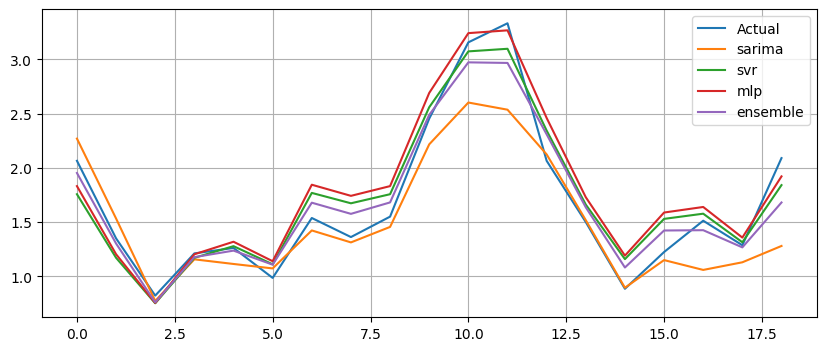

{'r2': 0.3709688299482158, 'rmse': 56.90085753619285, 'mse': 3237.707588354115}


In [8]:
pool_of_models = [SarimaModel, SVRModel, MLPModel]

result = run_grid_search_experiment(
    pool_of_models,
    run_dir='runs_gs/single_run',
    verbose=True
)
print(result)

# Repeated Experiments & Statistical Analysis

In [9]:
RUNS_DIR = 'runs_gs'
n_runs = 5  # grid search is deterministic; a few runs confirm consistency
pool_of_models = [SarimaModel, SVRModel, MLPModel]

print(f"Running {n_runs} independent experiments → {RUNS_DIR}/")
results = []

for i in range(n_runs):
    run_dir = os.path.join(RUNS_DIR, f'run_{i+1:02d}')
    res = run_grid_search_experiment(pool_of_models, run_dir=run_dir, show_plot=False)
    results.append({'run': i + 1, **res})
    print(f"  Run {i+1:>2}/{n_runs}  R²={res['r2']:.4f}  RMSE={res['rmse']:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(RUNS_DIR, 'all_results.csv'), index=False)

print(f"\nSaved → {RUNS_DIR}/all_results.csv")
print(results_df.describe())

Running 5 independent experiments → runs_gs/
  Run  1/5  R²=0.3710  RMSE=56.9009
  Run  2/5  R²=0.3710  RMSE=56.9009
  Run  3/5  R²=0.3710  RMSE=56.9009
  Run  4/5  R²=0.3710  RMSE=56.9009
  Run  5/5  R²=0.3710  RMSE=56.9009

Saved → runs_gs/all_results.csv
            run        r2          rmse          mse
count  5.000000  5.000000  5.000000e+00     5.000000
mean   3.000000  0.370969  5.690086e+01  3237.707588
std    1.581139  0.000000  7.944109e-15     0.000000
min    1.000000  0.370969  5.690086e+01  3237.707588
25%    2.000000  0.370969  5.690086e+01  3237.707588
50%    3.000000  0.370969  5.690086e+01  3237.707588
75%    4.000000  0.370969  5.690086e+01  3237.707588
max    5.000000  0.370969  5.690086e+01  3237.707588


=== Shapiro-Wilk normality test ===
  R²  : W=1.0000,  p=1.0000  → normal
  RMSE: W=1.0000, p=1.0000  → normal
  MSE : W=1.0000,  p=1.0000  → normal

=== Descriptive statistics ===
  R²  : mean=0.3710,  std=0.0000
  RMSE: mean=56.9009, std=0.0000
  MSE : mean=3237.7076,  std=0.0000


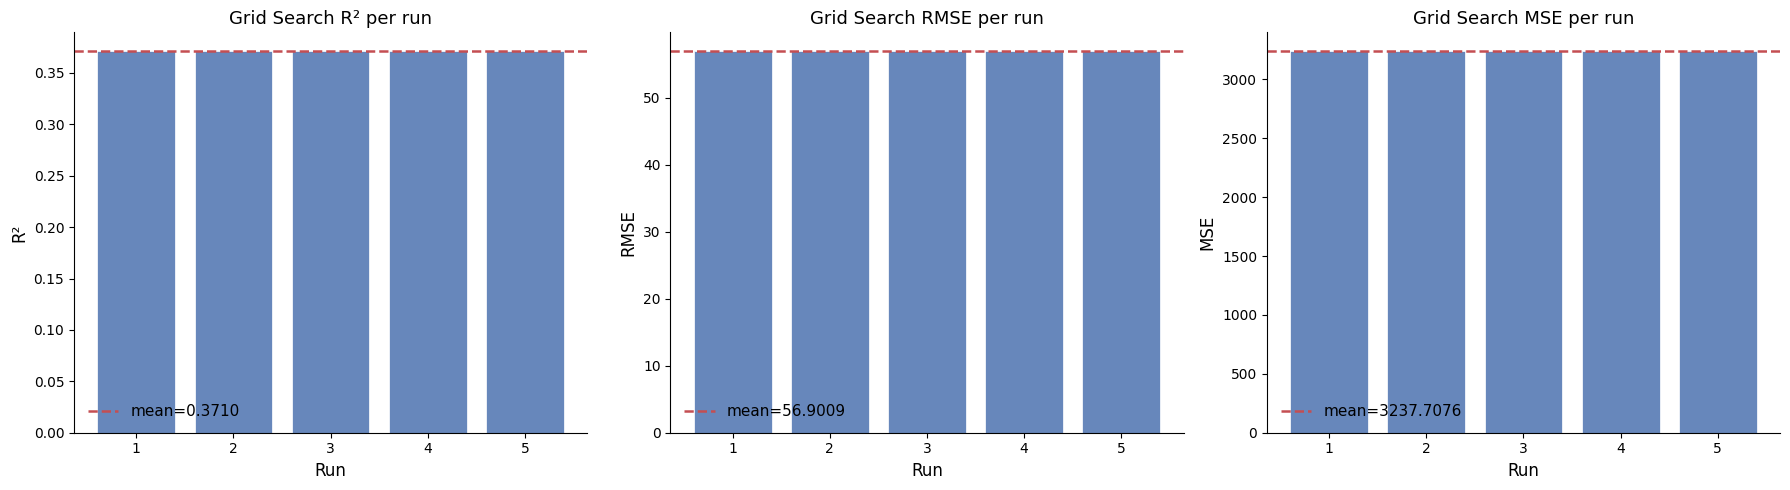

In [10]:
from scipy import stats

n = len(results_df)

sw_r2,   p_sw_r2   = stats.shapiro(results_df['r2'])
sw_rmse, p_sw_rmse = stats.shapiro(results_df['rmse'])
sw_mse,  p_sw_mse  = stats.shapiro(results_df['mse'])

print("=== Shapiro-Wilk normality test ===")
print(f"  R²  : W={sw_r2:.4f},  p={p_sw_r2:.4f}  → {'normal' if p_sw_r2 > 0.05 else 'non-normal'}")
print(f"  RMSE: W={sw_rmse:.4f}, p={p_sw_rmse:.4f}  → {'normal' if p_sw_rmse > 0.05 else 'non-normal'}")
print(f"  MSE : W={sw_mse:.4f},  p={p_sw_mse:.4f}  → {'normal' if p_sw_mse > 0.05 else 'non-normal'}")

print("\n=== Descriptive statistics ===")
print(f"  R²  : mean={results_df['r2'].mean():.4f},  std={results_df['r2'].std():.4f}")
print(f"  RMSE: mean={results_df['rmse'].mean():.4f}, std={results_df['rmse'].std():.4f}")
print(f"  MSE : mean={results_df['mse'].mean():.4f},  std={results_df['mse'].std():.4f}")

BAR_COLOR  = '#4C72B0'
MEAN_COLOR = '#C44E52'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label in [
    (axes[0], 'r2',   'R²'),
    (axes[1], 'rmse', 'RMSE'),
    (axes[2], 'mse',  'MSE'),
]:
    ax.bar(results_df['run'], results_df[col], color=BAR_COLOR, edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.axhline(results_df[col].mean(), color=MEAN_COLOR, linestyle='--', linewidth=1.8, label=f'mean={results_df[col].mean():.4f}')
    ax.set_title(f'Grid Search {label} per run', fontsize=13)
    ax.set_xlabel('Run', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(frameon=False, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RUNS_DIR, 'statistics.png'), dpi=150, bbox_inches='tight')
plt.show()

# Comparison: Genetic Algorithm vs Grid Search

In [11]:
ga_path = os.path.join('runs', 'all_results.csv')
gs_path = os.path.join('runs_gs', 'all_results.csv')

ga_df = pd.read_csv(ga_path)
gs_df = pd.read_csv(gs_path)

print("=== Genetic Algorithm ===")
print(ga_df[['r2', 'rmse', 'mse']].describe().loc[['mean', 'std', 'min', 'max']])

print("\n=== Grid Search ===")
print(gs_df[['r2', 'rmse', 'mse']].describe().loc[['mean', 'std', 'min', 'max']])

# Wilcoxon signed-rank test (non-parametric, suitable for small/non-normal samples)
from scipy.stats import mannwhitneyu, wilcoxon

print("\n=== Mann-Whitney U test (GA vs Grid Search) ===")
for col, label in [('r2', 'R²'), ('rmse', 'RMSE'), ('mse', 'MSE')]:
    u_stat, p_val = mannwhitneyu(ga_df[col], gs_df[col], alternative='two-sided')
    winner = 'GA' if ga_df[col].mean() > gs_df[col].mean() else 'Grid Search'
    if label == 'RMSE' or label == 'MSE':
        winner = 'GA' if ga_df[col].mean() < gs_df[col].mean() else 'Grid Search'
    sig = 'significant' if p_val < 0.05 else 'not significant'
    print(f"  {label}: U={u_stat:.1f}, p={p_val:.4f} ({sig}) — {winner} is better on average")

=== Genetic Algorithm ===
            r2       rmse          mse
mean  0.567923  46.255609  2223.958621
std   0.172648   9.424339   888.642990
min   0.198459  32.433600  1051.938423
max   0.795626  64.231125  4125.637363

=== Grid Search ===
            r2          rmse          mse
mean  0.370969  5.690086e+01  3237.707588
std   0.000000  7.944109e-15     0.000000
min   0.370969  5.690086e+01  3237.707588
max   0.370969  5.690086e+01  3237.707588

=== Mann-Whitney U test (GA vs Grid Search) ===
  R²: U=85.0, p=0.0186 (significant) — GA is better on average
  RMSE: U=15.0, p=0.0186 (significant) — GA is better on average
  MSE: U=15.0, p=0.0186 (significant) — GA is better on average


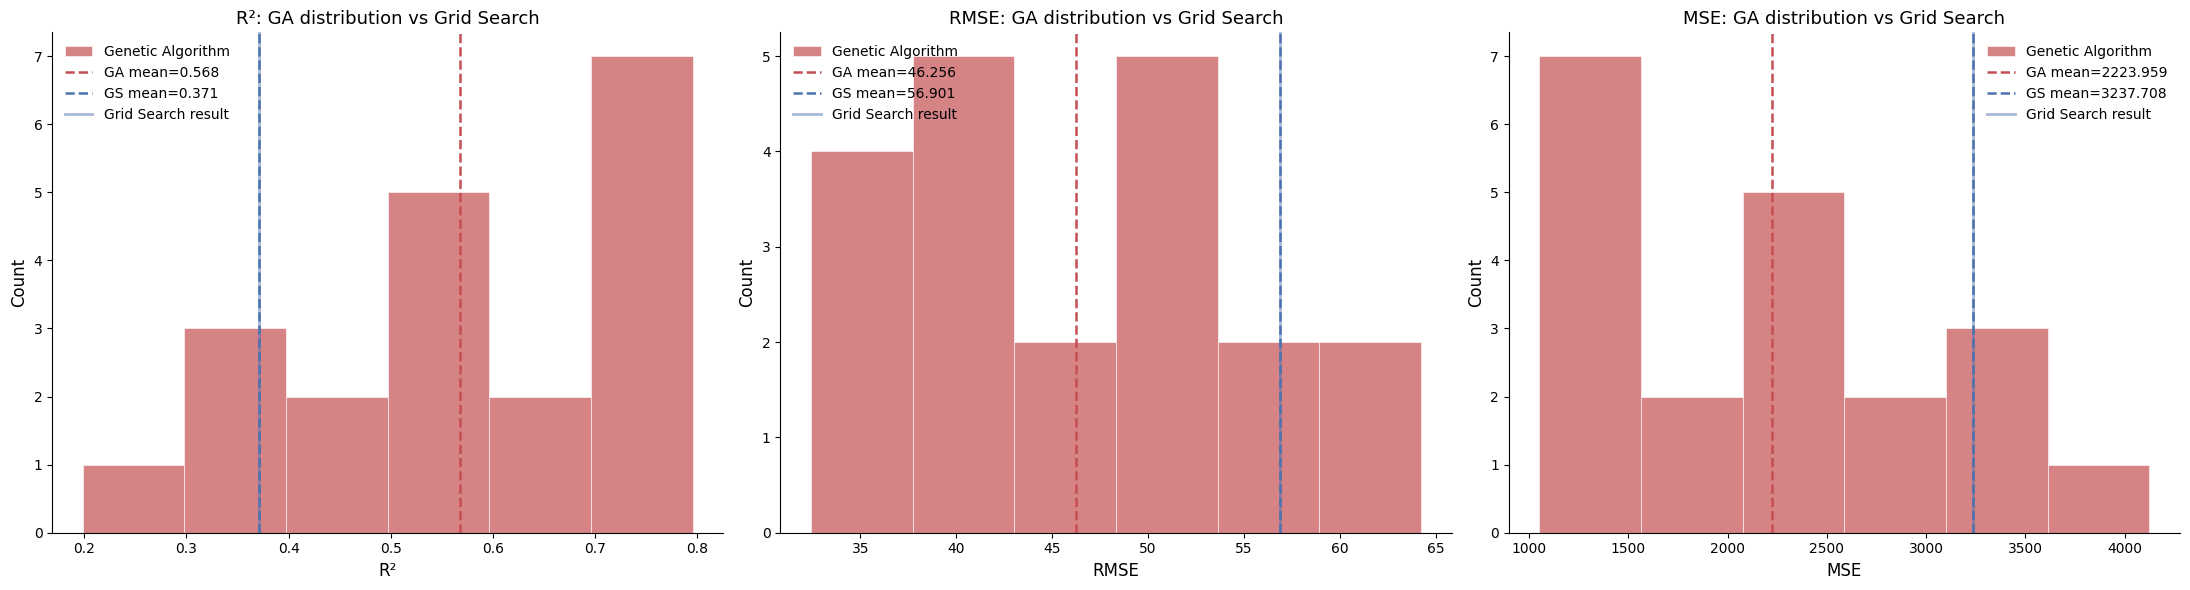

In [12]:
GA_COLOR = '#C44E52'
GS_COLOR = '#4C72B0'

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, col, label in [
    (axes[0], 'r2',   'R²'),
    (axes[1], 'rmse', 'RMSE'),
    (axes[2], 'mse',  'MSE'),
]:
    ax.hist(ga_df[col], bins='auto', alpha=0.7, color=GA_COLOR, edgecolor='white', linewidth=0.6, label='Genetic Algorithm')
    ax.axvline(ga_df[col].mean(), color=GA_COLOR, linestyle='--', linewidth=1.8, label=f'GA mean={ga_df[col].mean():.3f}')
    ax.axvline(gs_df[col].mean(), color=GS_COLOR, linestyle='--', linewidth=1.8, label=f'GS mean={gs_df[col].mean():.3f}')
    for v in gs_df[col].unique():
        ax.axvline(v, color=GS_COLOR, linewidth=2, alpha=0.5, label='Grid Search result' if v == gs_df[col].unique()[0] else '')
    ax.set_title(f'{label}: GA distribution vs Grid Search', fontsize=13)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()